In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
import math
import numpy as np
import itertools 
from itertools import product
from collections import Counter
import garpar as gp
import re
import skcriteria as skc
from skcriteria import pipelines
from skcriteria.preprocessing import invert_objectives, weighters, scalers
from skcriteria.preprocessing.increment import AddValueToZero
from skcriteria.madm import similarity, moora, electre
from skcriteria.ranksrev import RankInvariantChecker
from garpar.datasets import make_multisector, RissoLevyStable, RissoNormal, RissoUniform
import warnings

/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/madm.py:30: SKCriteriaDeprecationWarning: 'skcriteria.madm' module is deprecated, use 'skcriteria.agg' instead
  utils.deprecate.warn(deprecation_reason)
/home/nadia/indicador/lib/python3.10/site-packages/skcriteria/agg/similarity.py:27: SKCriteriaDeprecationWarning: The module 'skcriteria.agg.similarity' is deprecated since v0.9 and will be removed in v1.0. Please use 'skcriteria.agg.topsis' instead.
  deprecate.warn(


In [2]:
# --- 1. Definición de Nombres (Tickers) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

In [3]:
# --- 1. Configuración de Parámetros Fijos ---
NUM_ITERACIONES = 200
DIAS_SIMULACION = 40
VENTANAS_A_PROBAR = [3, 5, 7] 

# --- 2. Precios Iniciales (Lista Completa) ---
PRECIOS_INICIALES_TOTAL = [
    1515.00, 475.50, 200.00, 325.00,                      # AGRO (4)
    7000.00, 2490.00, 2725.00, 44.85, 1880.00, 840.00,    # COME (1-6)
    235.75, 2750.00, 2015.00, 710.00, 1300.00, 300.00,    # COME (7-12)
    20.90,                                                # COME (13)
    1655.00, 131.25, 1950.00, 4130.00, 3345.00, 7840.00,  # ENE (1-6)
    2630.00, 45600.00, 5150.00, 29.95, 407.00, 2420.00,   # ENE (7-12)
    1590.00, 1945.00, 2160.00, 2600.00,                   # ENE (13-16)
    7140.00, 9420.00, 206.75, 6870.00, 2830.00, 365.50,   # FIN (1-6)
    419.00, 2265.00,                                      # FIN (7-8)
    311.00, 2150.00, 5900.00, 400.00, 1010.00, 24450.00,  # MOA (1-6)
    3060.00, 224.00, 1500.00, 636.00, 25.55,              # MOA (7-11)
    787.00, 1550.00, 3195.00, 23500.00, 696.00, 49.60,    # MOI (1-6)
    70.00, 25.85, 240.00, 27.00, 670.00                   # MOI (7-11)
]
# --- DEFINICIÓN DE PARÁMETROS INDEPENDIENTES ---


params_COME = {"alpha": 1.740000, "beta": 0.999990, "mu": 0.000520, "sigma": 0.010091, "entropy": 0.99} # alpha bajó de 1.92 a 1.74

# Se redujo alpha de 1.62 a 1.55 para acentuar la pesadez de las colas.
params_MOA  = {"alpha": 1.550000, "beta": 0.580927, "mu": 0.001307, "sigma": 0.010535, "entropy": 0.99} 

# Se redujo alpha de 1.99 a 1.75 para romper la simetría casi normal.
params_MOI  = {"alpha": 1.750000, "beta": -0.172058, "mu": 0.000450, "sigma": 0.012284, "entropy": 0.99} 

# AGRO tenía un alpha de 1.99 (casi normal), se bajó a 1.75 para simular colas pesadas.
params_AGRO = {"alpha": 1.750000, "beta": 0.297929, "mu": 0.000234, "sigma": 0.013766, "entropy": 0.99} 

# ENE era una normal perfecta (alpha=2.0), se bajó a 1.89.
params_ENE  = {"alpha": 1.890000, "beta": -1.000000, "mu": 0.002323, "sigma": 0.018403, "entropy": 0.99} 

# FIN se ajustó de 1.90 a 1.70 para incrementar la probabilidad de outliers.
params_FIN  = {"alpha": 1.710000, "beta": -0.999973, "mu": -0.002929, "sigma": 0.017263, "entropy": 0.990}

# AJUSTE AUTOMÁTICO DE STOCKS_TOTALES
STOCKS_TOTALES = len(PRECIOS_INICIALES_TOTAL) # Esto ahora será 63

# --- 3. Definición de Parámetros (Asegurando 63 entradas) ---
# Usamos multiplicadores para no equivocarnos en la cuenta
parametros_sectores_base = (
    [params_AGRO] * 4 + 
    [params_COME] * 13 + 
    [params_ENE] * 16 + 
    [params_FIN] * 8 + 
    [params_MOA] * 11 + 
    [params_MOI] * 11
)

# Verificación de seguridad
if len(parametros_sectores_base) != STOCKS_TOTALES:
    print(f"ERROR: Tienes {len(parametros_sectores_base)} parámetros pero {STOCKS_TOTALES} precios.")

# --- 4. BUCLE DE SIMULACIÓN ---
resultados_por_ventana = {ventana: [] for ventana in VENTANAS_A_PROBAR}

for VENTANA in VENTANAS_A_PROBAR:
    print(f"Iniciando {NUM_ITERACIONES} simulaciones para Ventana: {VENTANA} días...")
    
    for i in range(NUM_ITERACIONES):
        random_seed_base = i * 10000 
        distribuciones_para_corrida = []
        
        for j, params in enumerate(parametros_sectores_base):
            semilla_sector = random_seed_base + (j * 100)
            params_corrida = params.copy() 
            params_corrida['random_state'] = semilla_sector
            # Se asume que RissoLevyStable está importada correctamente
            distribuciones_para_corrida.append(RissoLevyStable(**params_corrida))

        # SIMULACIÓN DEL MERCADO
        stocksset = make_multisector(
            *distribuciones_para_corrida,
            stocks=STOCKS_TOTALES,  
            days=DIAS_SIMULACION,
            window_size=VENTANA,
            price=PRECIOS_INICIALES_TOTAL 
        )
        
        df_simulacion = stocksset._prices_df 
        resultados_por_ventana[VENTANA].append(df_simulacion)
    
print("\n--- ¡Generación de Simulaciones Finalizada! ---")

Iniciando 200 simulaciones para Ventana: 3 días...
Iniciando 200 simulaciones para Ventana: 5 días...
Iniciando 200 simulaciones para Ventana: 7 días...

--- ¡Generación de Simulaciones Finalizada! ---


In [4]:
# --- 5. Definición de Nombres de Acciones (Fuera del bucle) ---
nombres_acciones = [
    "CRES", "CADO", "GARO", "INVJ",                                     # AGRO
    "CVH", "TECO2", "AUSO", "BOLT", "CTIO", "DYCA", "GAMI", "GCLA",     # COME (1-8)
    "IRSA", "OEST", "PATA", "POLL", "TGLT",                             # COME (9-13)
    "CEPU", "COME", "EDN", "PAMP", "TGNO4", "TGSU2", "TRAN", "YPFD",    # ENE (1-8)
    "CAPX", "CARC", "CECO2", "CGPA2", "DGCU2", "GBAN", "METR", "MTR",   # ENE (9-16)
    "BBAR", "BMA", "BYMA", "GGAL", "SUPV", "VALO", "BHIP", "BPAT",      # FIN
    "CELU", "GRIM", "HAVA", "INTR", "LEDE", "MOLA", "MOLI", "MORI",     # MOA (1-8)
    "RICH", "SAMI", "SEMI",                                             # MOA (9-11)
    "ALUA", "HARG", "LOMA", "MIRG", "TXAR", "AGRO", "DOME", "FERR",     # MOI (1-8)
    "FIPL", "LONG", "RIGO"                                              # MOI (9-11)
]

# --- 6. Ensamblado: Asignación de Nombres a los DataFrames Resultantes ---
# Recorremos el diccionario generado en el paso 4 y renombramos las columnas
for ventana in VENTANAS_A_PROBAR:
    for df in resultados_por_ventana[ventana]:
        # Asignamos los nombres directamente a las columnas del DataFrame
        df.columns = nombres_acciones

print("--- Nombres de acciones integrados correctamente en todos los DataFrames ---")

--- Nombres de acciones integrados correctamente en todos los DataFrames ---


In [5]:
# --- 0. CONFIGURACIÓN INICIAL ---
# Suprimir el warning común de garpar/pypfopt sobre matrices no positivas
warnings.filterwarnings('ignore', category=UserWarning, message='The covariance matrix is non positive semidefinite. Amending eigenvalues.')
warnings.filterwarnings('ignore', category=UserWarning, message="No risk_free_rate specified, coercing it")
# ⚠️ DEFINICIÓN DE LOS OPTIMIZADORES A PROBAR (Asumida)
optimizadores_a_probar = {
   "Sharpe": gp.optimize.mean_variance.MVOptimizer(model='max_sharpe'),
    "Markowitz s.a ret 0.001": gp.optimize.mean_variance.Markowitz(target_return=0.001),
    "Markowitz s.a ret 0.01": gp.optimize.mean_variance.Markowitz(target_return=0.01),
    "Markowitz s.a. riesgo 0.20 ": gp.optimize.mean_variance.Markowitz(target_risk=0.20),
    "Markowitz s.a. riesgo 0.25 ": gp.optimize.mean_variance.Markowitz(target_risk=0.25),
    "Markowitz s.a. riesgo 0.30 ": gp.optimize.mean_variance.Markowitz(target_risk=0.30),


}

rows = []

print("--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---")

# --- 1. BUCLE DE PROCESAMIENTO SOBRE LOS RESULTADOS GUARDADOS ---

for VENTANA, lista_simulaciones in resultados_por_ventana.items():
    
    for i, df_corrida in enumerate(lista_simulaciones):
        
        corrida_id = i + 1
        stocks_number_base = len(df_corrida.columns)

        # 💡 MEJORA DE ROBUSTEZ: Intentar crear el StocksSet primero
        stocksset_corrida = None
        try:
            stocksset_corrida = gp.StocksSet.from_prices(df_corrida, window_size=VENTANA)
        except Exception as e:
            # Si el StocksSet falla (ej: datos malformados), registra el fallo para TODOS los modelos
            print(f"⚠️ Error al crear StocksSet (Corrida {corrida_id}, Ventana {VENTANA}): {e}. Saltando modelos.")
            
            for opt_name in optimizadores_a_probar.keys():
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            continue # Pasa a la siguiente corrida
        
        # 2. ITERACIÓN SOBRE LOS MODELOS DE OPTIMIZACIÓN
        for opt_name, optimizador in optimizadores_a_probar.items():
            
            try:
                # 3. OPTIMIZACIÓN + PRUNING
                mopt = optimizador.optimize(stocksset_corrida).weights_prune()
                
                # 4. CÁLCULO DE MÉTRICAS (EXITOSO)
                metricas = {
                    "stocks_number": len(mopt.stocks),
                    "Cross_Entropy": mopt.div.cross_entropy(),
                    "Zheng_Entropy": mopt.div.zheng_entropy(),
                    "Div_Ratio": mopt.div.ratio(),
                    "CV_MC": (mopt.div.mrc() * mopt.weights).std() / (mopt.div.mrc() * mopt.weights).mean(),
                    "PDI": mopt.div.pdi(n_components=3, random_state=100)
                }

                # 5. GUARDAR RESULTADO EXITOSO
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name, 
                    **metricas
                })

            except Exception as e:
                #  Garantizar que la fila de identificadores se guarde
                rows.append({
                    "Ventana": VENTANA,
                    "Corrida": corrida_id,
                    "Modelo_Opt": opt_name,
                    "stocks_number": stocks_number_base, 
                    "Cross_Entropy": np.nan,
                    "Zheng_Entropy": np.nan,
                    "Div_Ratio": np.nan,
                    "CV_MC": np.nan,
                    "PDI": np.nan
                })
            
# --- 2. CREACIÓN DEL DATAFRAME FINAL ---

df_metricas_simulacion = pd.DataFrame(rows)

# Esta línea ahora es segura, ya que 'rows' garantiza las claves de índice
df_metricas_simulacion = df_metricas_simulacion.set_index(["Ventana", "Corrida", "Modelo_Opt"])

print("\n--- ANÁLISIS COMPLETADO ---")
print(f"Total de resultados guardados: {len(df_metricas_simulacion)} filas.")
print(df_metricas_simulacion.head(9))


--- INICIO DEL PROCESAMIENTO DE MÉTRICAS (Usando StocksSet) ---


/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadia/indicador/lib/python3.10/site-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(
/home/nadi


--- ANÁLISIS COMPLETADO ---
Total de resultados guardados: 3600 filas.
                                             stocks_number  Cross_Entropy  \
Ventana Corrida Modelo_Opt                                                  
3       1       Sharpe                                  33       0.356800   
                Markowitz s.a ret 0.001                 33       0.309493   
                Markowitz s.a ret 0.01                  33       0.309493   
                Markowitz s.a. riesgo 0.20              10       0.780428   
                Markowitz s.a. riesgo 0.25              10       5.352621   
                Markowitz s.a. riesgo 0.30               5       0.331651   
        2       Sharpe                                  33       0.405289   
                Markowitz s.a ret 0.001                 38       0.562031   
                Markowitz s.a ret 0.01                  38       0.562031   

                                             Zheng_Entropy  Div_Ratio  \
Ventana

In [6]:
#Eliminar corridas con NaN ===
# =========================================================================

# 1. Identificar el nivel del índice que representa la "corrida"
LEVEL_CORRIDA = 'Corrida' 

# 2. Inicializar una lista para guardar las corridas (índices) que deben eliminarse
corridas_a_eliminar = set()

# 3. Iterar sobre las corridas (grupos) para verificar NaNs
for corrida_id, group_df in df_metricas_simulacion.groupby(level=LEVEL_CORRIDA):
    
    # 4. Verificar si existe AL MENOS UN NaN en CUALQUIERA de las filas
    # .isnull() crea un DF booleano, .any(axis=None) verifica si hay True en todo el grupo.
    if group_df.isnull().any().any(): 
        # Si se encuentra un NaN, se añade el ID de la corrida a la lista de eliminación
        corridas_a_eliminar.add(corrida_id)

# 5. Filtrar el DataFrame original, excluyendo las corridas identificadas
# Creamos una máscara booleana: True para las corridas que NO están en la lista
mascara_mantener = ~df_metricas_simulacion.index.get_level_values(LEVEL_CORRIDA).isin(corridas_a_eliminar)

# Aplicar la máscara al DataFrame
df_metricas_limpio = df_metricas_simulacion[mascara_mantener]


In [7]:
df_metricas_limpio[df_metricas_limpio.index.get_level_values('Ventana') == 3].describe()

,stocks_number,Cross_Entropy,Zheng_Entropy,Div_Ratio,CV_MC,PDI
count,792.000000,792.000000,792.000000,7.920000e+02,7.920000e+02,792.000000
mean,23.395202,1.481504,2.464252,2.331291e+05,1.655239e+05,0.994391
std,14.148182,1.906276,0.809348,3.014694e+06,3.158416e+06,0.542589
min,3.000000,0.006155,0.357650,7.404339e-02,2.625535e-01,0.024680
25%,10.000000,0.394617,1.740679,1.555379e-01,8.998974e-01,0.538356
50%,27.500000,0.527376,2.660336,3.087068e-01,1.709008e+00,0.990159
75%,35.000000,2.001051,3.215497,2.359424e+00,3.087073e+00,1.357752
max,63.000000,10.710938,3.620325,5.138932e+07,8.076994e+07,2.811927


In [8]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 3
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_3 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v3 = df_ventana_3.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v3;


In [9]:
len(corridas_existentes_v3)


132

In [10]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v3:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_3[df_ventana_3.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm



In [11]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    # CAMBIO 1: Se agrega AddValueToZero al inicio para evitar divisiones por cero posteriores
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(), 
)

# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v3:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v3 = pd.concat(resultados_similaridad)
    df_similaridad_total_v3.index.name = 'Corrida'
else:
    df_similaridad_total_v3 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v3

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.602671,0.642209,0.642209,0.503740,0.212461,0.587040
2,0.659666,0.728117,0.728117,0.202211,0.428872,0.408346
3,0.560086,0.651917,0.651917,0.359828,0.412648,0.407409
8,0.538271,0.674865,0.674865,0.433684,0.259754,0.443423
11,0.686860,0.904762,0.904762,0.195543,0.512496,0.560497
...,...,...,...,...,...,...
191,0.686815,0.719634,0.719402,0.500781,0.442023,0.170229
192,0.820563,0.819282,0.819282,0.156337,0.388895,0.505791
196,0.444583,0.643249,0.643249,0.318480,0.345040,0.451266


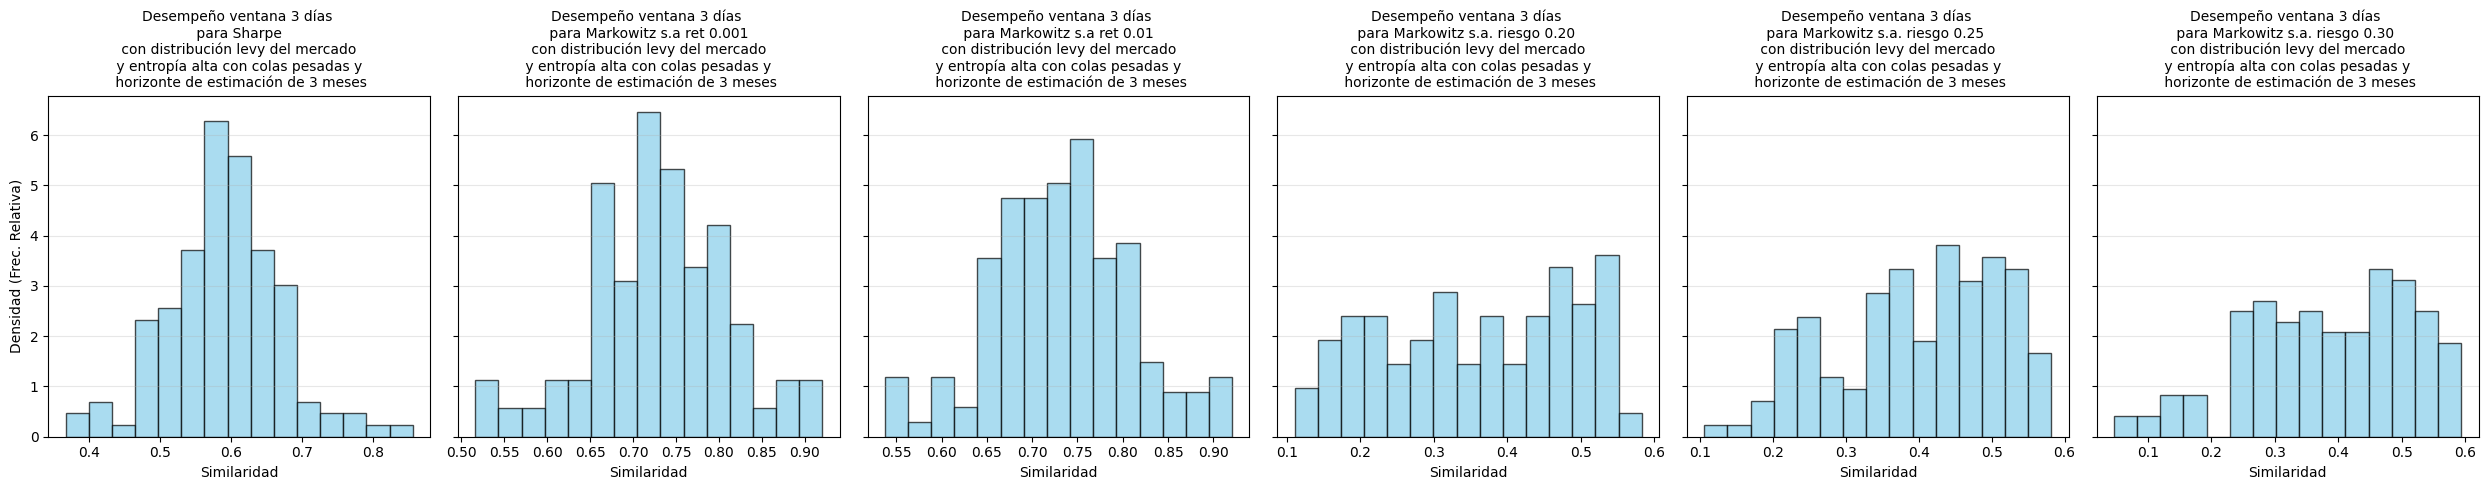

In [12]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v3.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v3[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 3 días \n para {modelo} \n con distribución levy del mercado \n y entropía alta con colas pesadas y \n horizonte de estimación de 3 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_hist_v3_mdocp_ae", dpi=300, bbox_inches='tight')

In [13]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 5
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_5 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v5 = df_ventana_5.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v5;


In [14]:
len(corridas_existentes_v5)

132

In [15]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v5:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_5[df_ventana_5.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [16]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v5:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v5 = pd.concat(resultados_similaridad)
    df_similaridad_total_v5.index.name = 'Corrida'
else:
    df_similaridad_total_v5 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v5

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.612222,0.681664,0.681664,0.226781,0.557853,0.535637
2,0.656898,0.900856,0.900856,0.498629,0.323848,0.135697
3,0.415058,0.671306,0.671306,0.430984,0.557876,0.542569
8,0.593785,0.714569,0.714569,0.193265,0.396609,0.365912
11,0.609046,0.773667,0.773667,0.253331,0.226090,0.390140
...,...,...,...,...,...,...
191,0.688026,0.841737,0.841737,0.519366,0.125516,0.508720
192,0.661544,0.844267,0.845194,0.136097,0.496438,0.525269
196,0.610596,0.648409,0.648409,0.492904,0.350756,0.449241


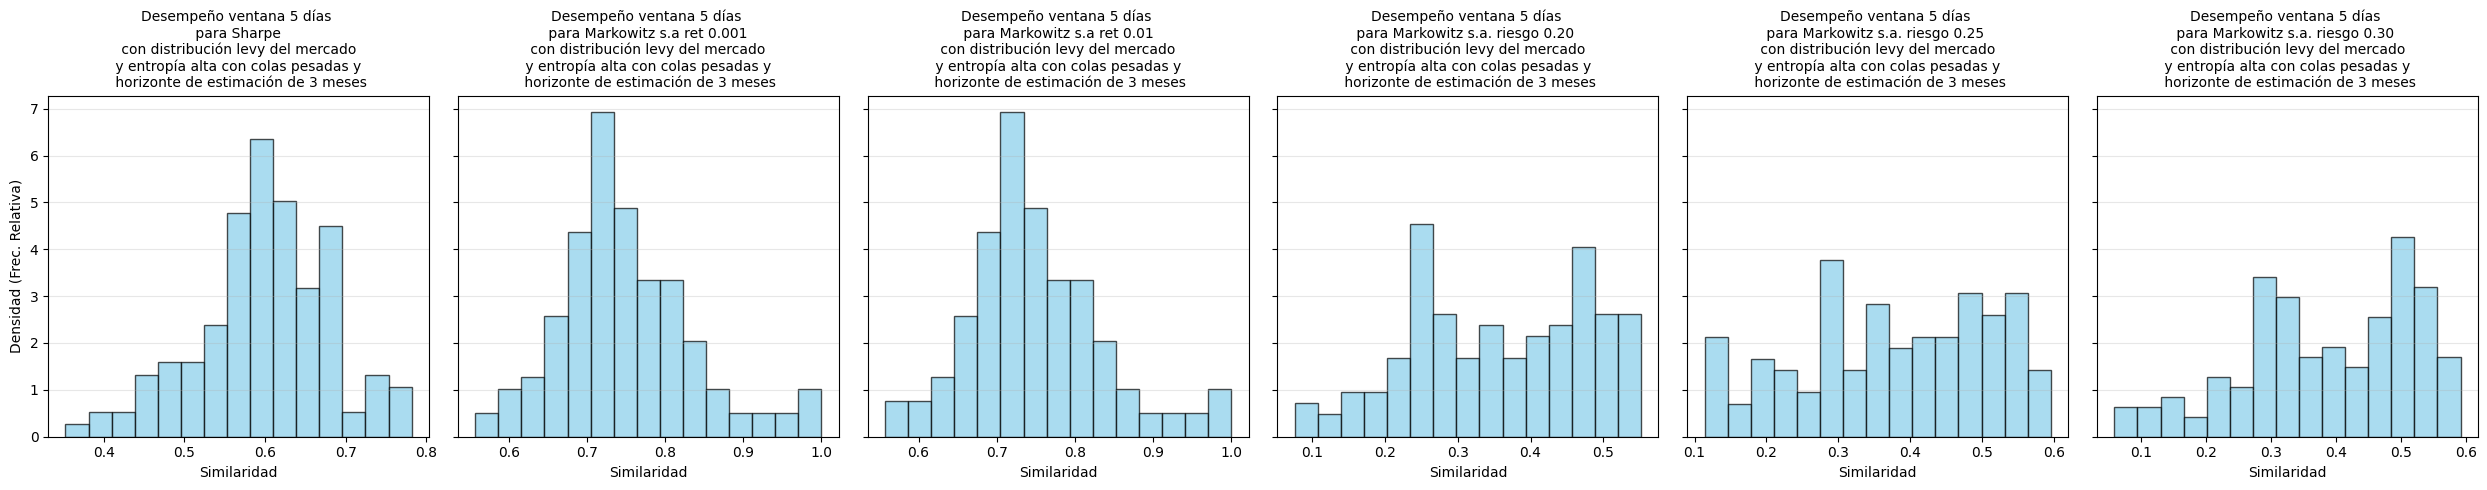

In [17]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v5.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v5[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 5 días \n para {modelo} \n con distribución levy del mercado \n y entropía alta con colas pesadas y \n horizonte de estimación de 3 meses', fontsize=10)

    ax.set_xlabel('Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_hist_v5_mdocp_ae", dpi=300, bbox_inches='tight')

In [18]:
# =========================================================================
# === Definiciones 
# =========================================================================

# 1. Definición de Objetivos (idéntica a tu código)
objectives = [
    max, # 'stocks_number'
    min, # 'Cross_Entropy'
    max, # 'Zheng_Entropy'
    max, # 'Div_Ratio'
    min, # 'CV_MC'
    max, # 'PDI'
]

# 2. Identificar el nivel 'Ventana' que quieres filtrar (parece ser '3')
VENTANA_FILTRO = 7
LEVEL_VENTANA = 'Ventana'
LEVEL_CORRIDA = 'Corrida'

# 3. Filtrar por Ventana = 3 (esto simplifica la iteración)
df_ventana_7 = df_metricas_limpio[
    df_metricas_limpio.index.get_level_values(LEVEL_VENTANA) == VENTANA_FILTRO].copy()

# === PASO CRÍTICO: OBTENER LOS IDs DE CORRIDA REALES ===
# =========================================================================
# Obtenemos la lista ÚNICA de los identifi}cadores de corrida que existen 
corridas_existentes_v7 = df_ventana_7.index.get_level_values('Corrida').unique().tolist()
corridas_existentes_v7;

In [19]:
len(corridas_existentes_v7)

132

In [20]:
# Diccionario para almacenar las Matrices de Decisión generadas
matrices_decision = {}

# Iteramos sobre los IDs de corrida REALES (ej: '10', '11'...)
for el_corrida_id in corridas_existentes_v7:

    # 1. Filtramos el DataFrame de MÉTRICAS para la corrida actual
    df_filtrado = df_ventana_7[df_ventana_7.index.get_level_values('Corrida') == el_corrida_id].droplevel(['Ventana', 'Corrida'])
    
    # 2. ACCESO AL DATAFRAME ORIGINAL DE PESOS (Variable nueva solicitada)

    # === Extracción de elementos para skcriteria ===
    data = df_filtrado.to_numpy() 
    alternatives = df_filtrado.index 
    criteria = df_filtrado.columns 
    
    # === Generar la Matriz de Decisión ===
    dm = skc.mkdm(
        data, 
        objectives=objectives,
        alternatives=alternatives, 
        criteria=criteria
    )
    
    # Guardar la DM
    matrices_decision[el_corrida_id] = dm


In [21]:
# 1. Definición del Pipeline
pipe_igual_vector = pipelines.mkpipe(
    AddValueToZero(target="matrix", value=1e-10), 
    invert_objectives.NegateMinimize(),
    scalers.VectorScaler(target="matrix"),
    weighters.EqualWeighter(),
    similarity.TOPSIS(),
)
# VARIABLE NUEVA: Lista para acumular los resultados de similaridad
resultados_similaridad = []

for el_corrida_id in corridas_existentes_v7:
    
    # 1. Recuperamos la DM del diccionario generado anteriormente
    dm = matrices_decision[el_corrida_id]
    
   
    # CAMBIO 3: Bloque try-except para capturar si una matriz es totalmente constante
    try:
        # 2. Ejecución del pipeline
        result_igual_vector = pipe_igual_vector.evaluate(dm)
        
        # === CORRECCIÓN DEL ERROR Y CAMBIO DE NOMBRE ===
        # Convertimos el array de numpy (result_igual_vector.e_.similarity) a DataFrame
        df_similaridad_parcial = pd.DataFrame(
            [result_igual_vector.e_.similarity], 
            columns=dm.alternatives, 
            index=[el_corrida_id]
        )
        
        # 3. Guardamos en la lista para concatenar después
        resultados_similaridad.append(df_similaridad_parcial)
        
    except Exception as e:
        # CAMBIO 4: Manejo de errores para evitar que el bucle se detenga por datos inválidos
        print(f"Error en la corrida {el_corrida_id}: {e}")
        continue

# 4. CREACIÓN DEL DATAFRAME FINAL
if resultados_similaridad:
    df_similaridad_total_v7 = pd.concat(resultados_similaridad)
    df_similaridad_total_v7.index.name = 'Corrida'
else:
    df_similaridad_total_v7 = pd.DataFrame()

# Visualizar resultado consolidado de similaridad
df_similaridad_total_v7

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
Corrida,,,,,,
1,0.635868,0.701879,0.701879,0.482014,0.578235,0.284410
2,0.629823,0.709671,0.709671,0.345781,0.548195,0.262841
3,0.597864,0.761465,0.761465,0.486937,0.285914,0.546334
8,0.613814,0.681968,0.681968,0.375104,0.224683,0.491512
11,0.554064,0.706248,0.706248,0.535385,0.271328,0.528160
...,...,...,...,...,...,...
191,0.647768,0.706617,0.706617,0.274401,0.534779,0.477843
192,0.609852,0.746056,0.746056,0.246076,0.245027,0.374708
196,0.441860,0.557703,0.557703,0.506402,0.481986,0.522471


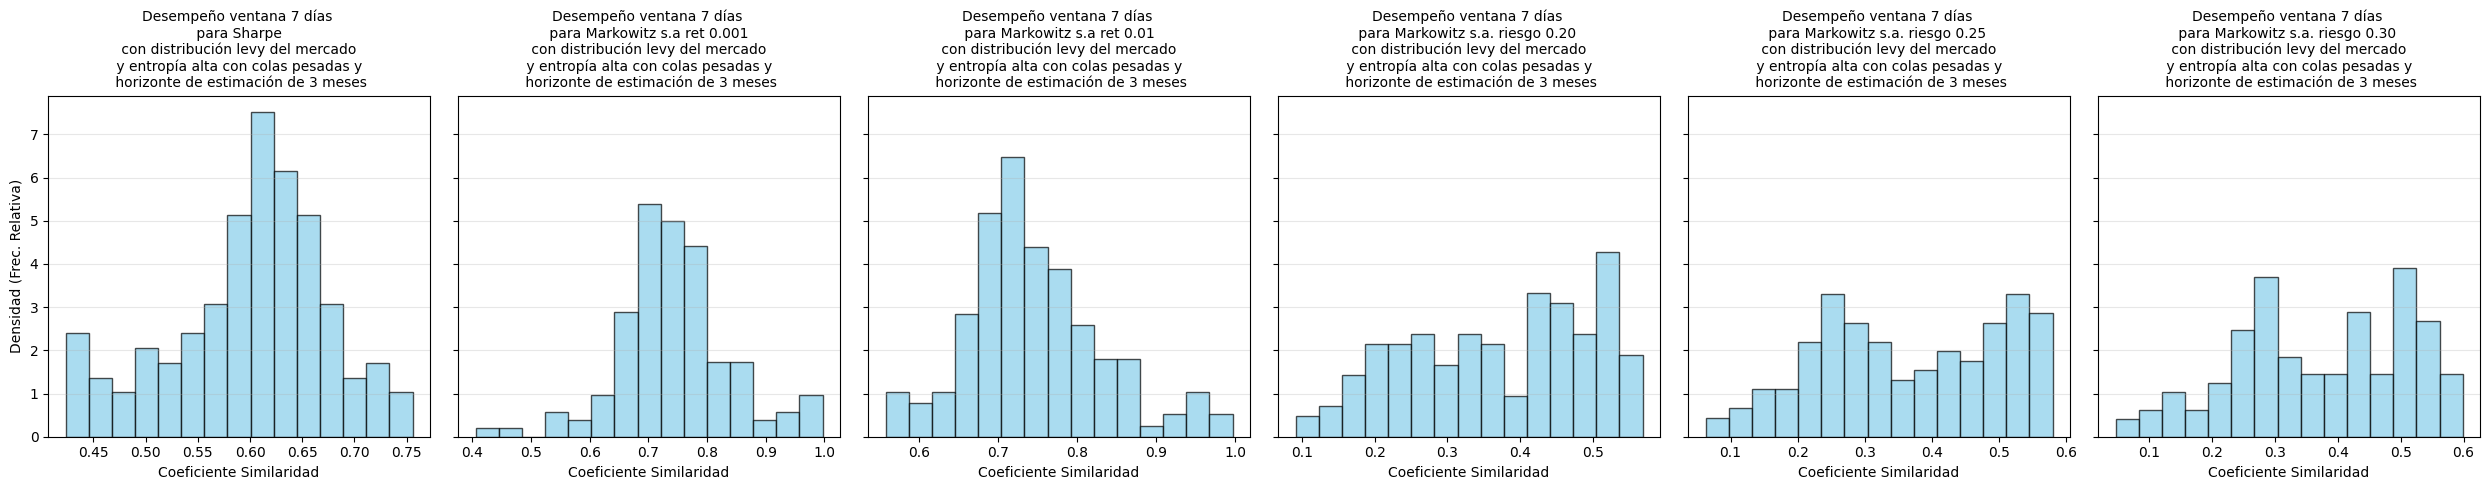

In [22]:
# 1. Configuración de la grilla (Forzada a 1 fila de 5 columnas)
modelos = df_similaridad_total_v7.columns
n_modelos = len(modelos)
n_cols = 6  # Cambiado a 5 para que entren todos en una fila
n_rows = 1  # Forzado a 1 renglón

# 2. Crear la figura y los subplots
# He aumentado el ancho (25) para que los 5 gráficos tengan espacio
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5), sharey=True, sharex=False)

# 3. Bucle para generar cada histograma
for i, modelo in enumerate(modelos):
    # Si solo hay una fila, axes puede no ser una matriz, lo tratamos con cuidado
    ax = axes[i] if n_modelos > 1 else axes
    
    # Generar el histograma con densidad
    ax.hist(df_similaridad_total_v7[modelo], bins=15, color='skyblue', 
            edgecolor='black', alpha=0.7, density=True)
    
    # Configuración del título
    ax.set_title(f'Desempeño ventana 7 días \n para {modelo} \n con distribución levy del mercado \n y entropía alta con colas pesadas y \n horizonte de estimación de 3 meses' , fontsize=10)

    ax.set_xlabel('Coeficiente Similaridad')
    # Solo ponemos el label del eje Y en el primero para no saturar
    if i == 0:
        ax.set_ylabel('Densidad (Frec. Relativa)')
        
    ax.grid(axis='y', alpha=0.3)

# 4. Limpiar subplots vacíos (en caso de que haya menos de 5 modelos)
if n_modelos < n_cols:
    for j in range(i + 1, n_cols):
        fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_hist_v7_mdocp_ae", dpi=300, bbox_inches='tight')

/tmp/ipykernel_31706/908966790.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
/tmp/ipykernel_31706/908966790.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
/tmp/ipykernel_31706/908966790.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)


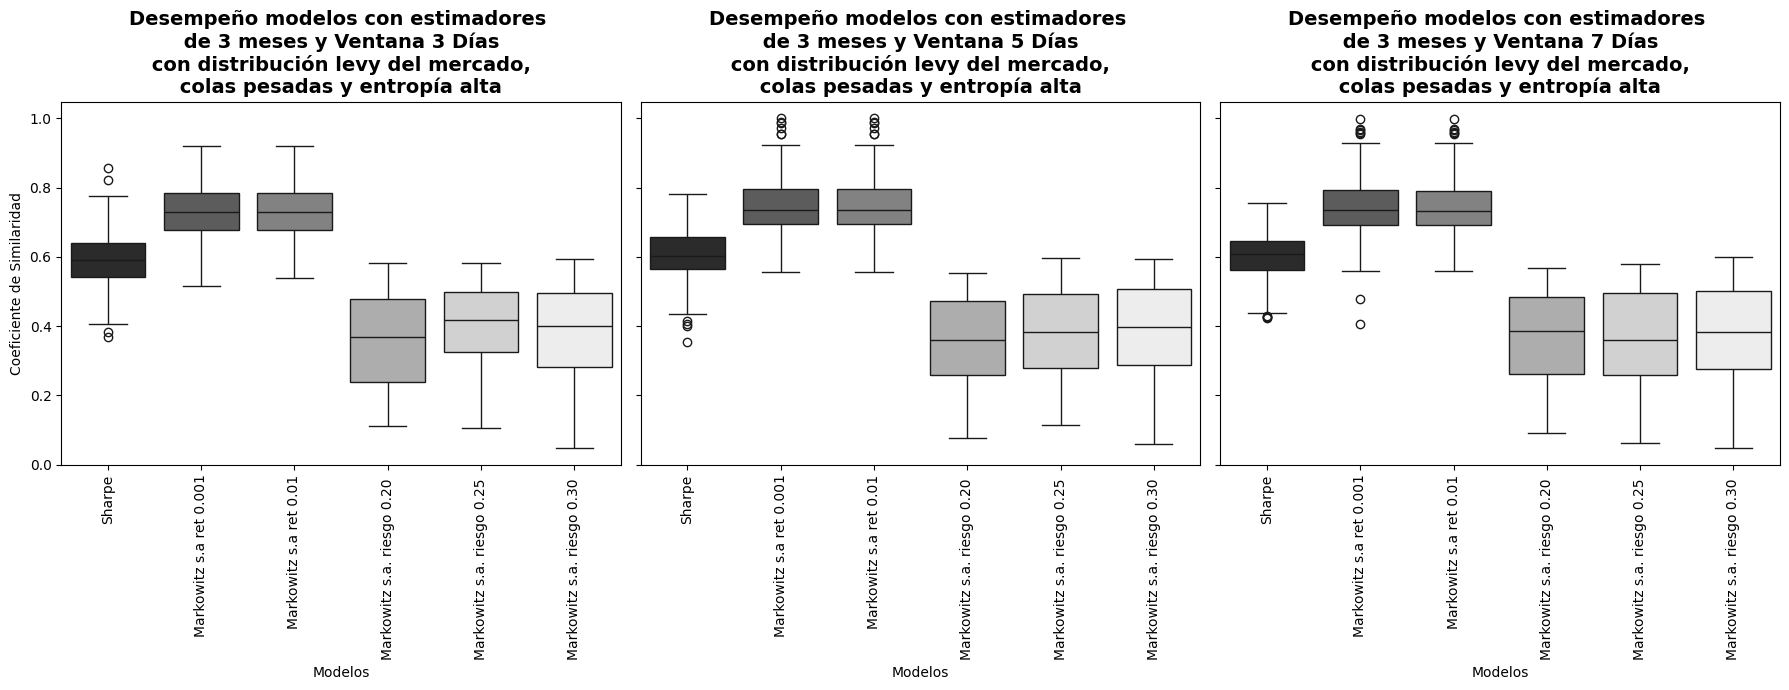

In [23]:
# 1. Configuración de la figura: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

# 2. Gráfico 1: Ventana 3 días
sns.boxplot(
    data=df_similaridad_total_v3, 
    ax=axes[0], 
    palette="Greys_r"
)
axes[0].set_title('Desempeño modelos con estimadores \n de 3 meses y Ventana 3 Días \n con distribución levy del mercado, \n colas pesadas y entropía alta ', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(df_similaridad_total_v3.columns, rotation=90)
axes[0].set_ylabel('Coeficiente de Similaridad')
axes[0].set_xlabel('Modelos')

# 3. Gráfico 2: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v5, 
    ax=axes[1], 
    palette="Greys_r"
)
axes[1].set_title('Desempeño modelos con estimadores \n de 3 meses y Ventana 5 Días \n con distribución levy del mercado, \n colas pesadas y entropía alta ', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(df_similaridad_total_v5.columns, rotation=90)
axes[1].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[1].set_xlabel('Modelos')

# 3. Gráfico 3: Ventana 5 días
sns.boxplot(
    data=df_similaridad_total_v7, 
    ax=axes[2], 
    palette="Greys_r"
)
axes[2].set_title('Desempeño modelos con estimadores \n de 3 meses y Ventana 7 Días \n con distribución levy del mercado, \n colas pesadas y entropía alta ', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(df_similaridad_total_v7.columns, rotation=90)
axes[2].set_ylabel('') # Quitamos el label porque comparten eje Y
axes[2].set_xlabel('Modelos')


# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_box_comp_v_mdocp_ae", dpi=300, bbox_inches='tight')

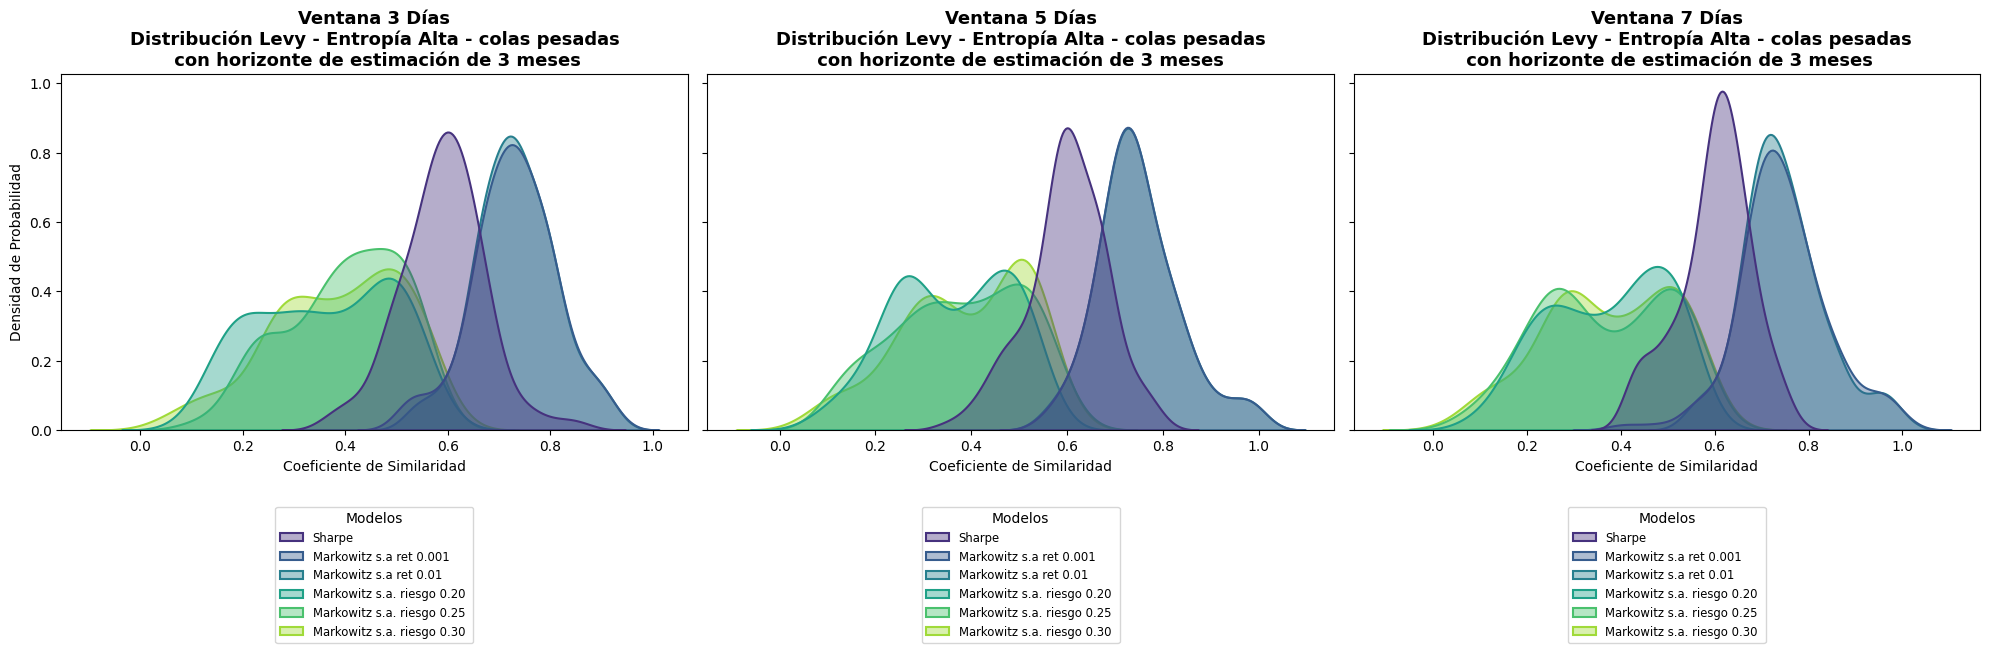

In [24]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses',
    'Ventana 5 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses ',
    'Ventana 7 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        fill=True,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_kde_comp_v_mdocp_ae", dpi=300, bbox_inches='tight')

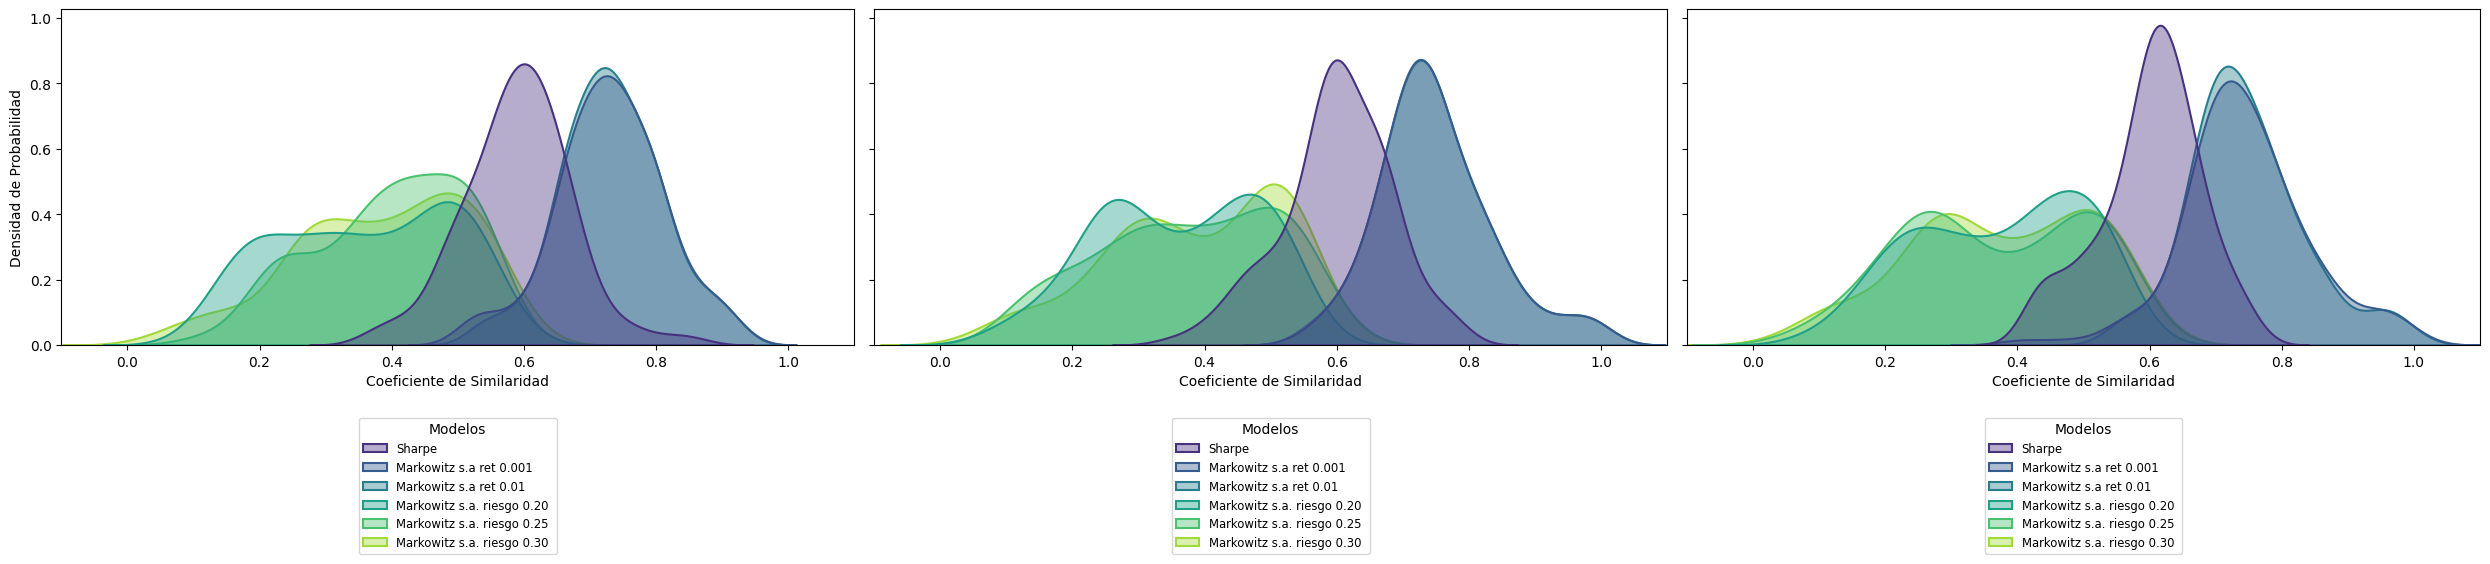

In [25]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(25, 6), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    '',
    '',
    ''
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        fill=True,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    # --- AJUSTE DE EJES ---
    axes[i].set_xlim(-0.10, 1.1) # Fija el rango del eje X
    # ----------------------
    
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/6si_Ci_kde_comp_v_mdocp_ae", dpi=300, bbox_inches='tight')

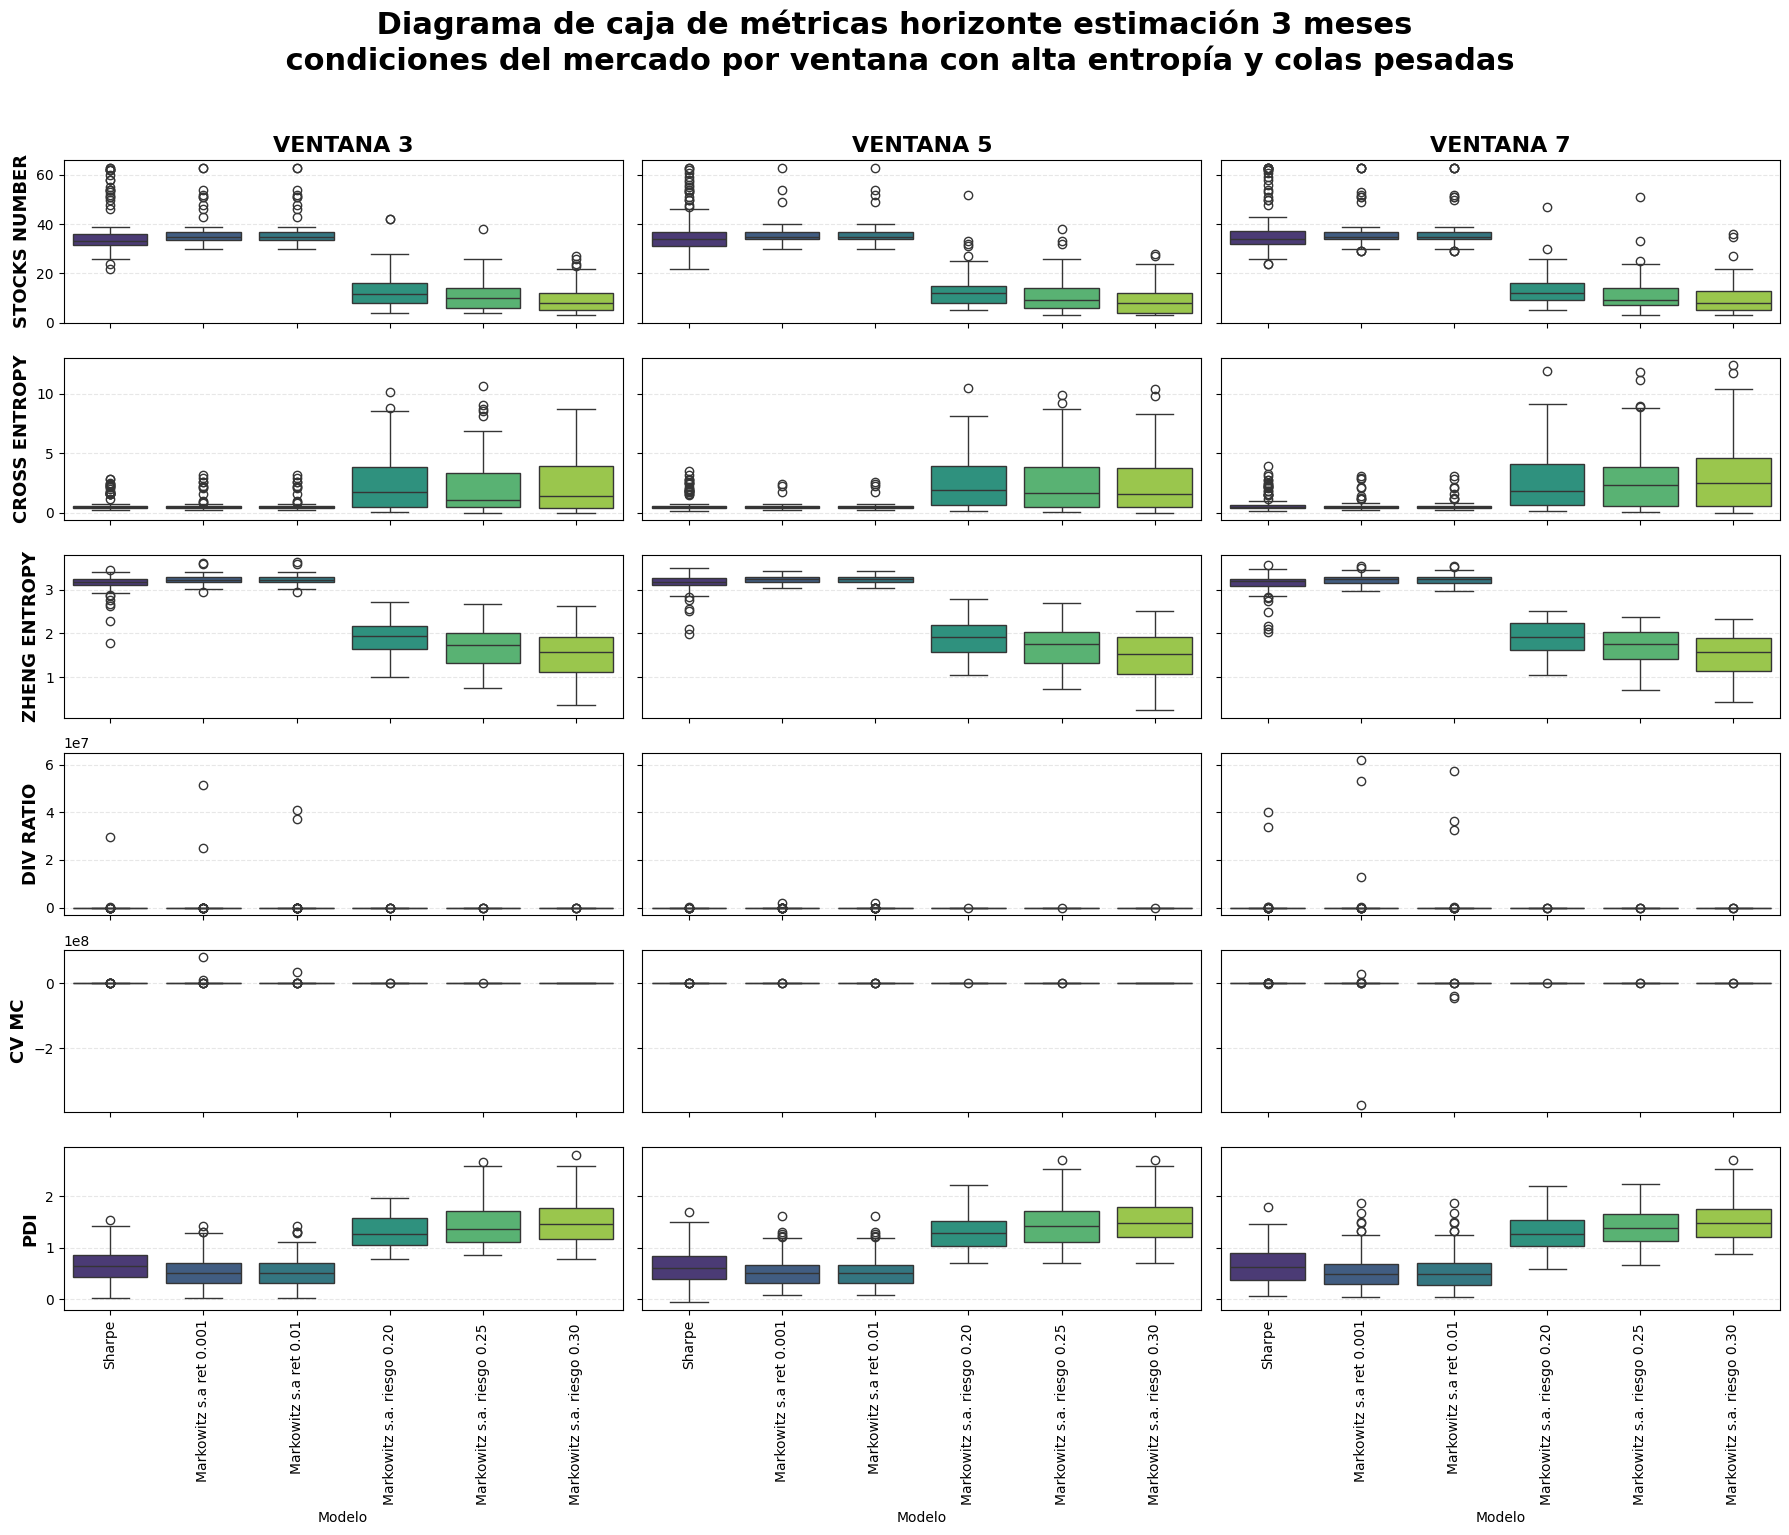

In [26]:
# Silenciamos advertencias para una salida limpia
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Configuración de parámetros y métricas
metricas = ['stocks_number', 'Cross_Entropy', 'Zheng_Entropy', 'Div_Ratio', 'CV_MC', 'PDI']
ventanas_deseadas = [3, 5, 7] 
ventanas_presentes = [v for v in ventanas_deseadas if v in df_metricas_limpio.index.get_level_values('Ventana')]

# 2. Crear la grilla con SHAREY por FILA (métrica) y SHAREX global
# Usamos sharey='row' para que la escala sea comparable entre ventanas para una misma métrica
fig, axes = plt.subplots(nrows=len(metricas), ncols=len(ventanas_presentes), 
                         figsize=(6 * len(ventanas_presentes), 2.5 * len(metricas)), 
                         sharex=True, sharey='row')

fig.suptitle(' Diagrama de caja de métricas horizonte estimación 3 meses \n condiciones del mercado por ventana con alta entropía y colas pesadas', fontsize=22, fontweight='bold', y=1.02)

# 3. Bucle doble: Métrica (Fila) e itera por Ventana (Columna)
for i, col in enumerate(metricas):
    for j, ventana in enumerate(ventanas_presentes):
        ax = axes[i, j]
        
        # Filtramos la ventana actual del DataFrame original
        df_ventana = df_metricas_limpio.xs(ventana, level='Ventana').reset_index()
        
        # Graficamos con corrección de FutureWarning
        sns.boxplot(
            data=df_ventana, 
            x='Modelo_Opt', 
            y=col, 
            ax=ax, 
            palette='viridis', 
            hue='Modelo_Opt',
            legend=False
        )
        
        # Estética de Encabezados (solo primera fila)
        if i == 0:
            ax.set_title(f'VENTANA {ventana}', fontsize=16, fontweight='bold')
        
        # Estética de Etiquetas (solo primera columna para evitar redundancia con sharey)
        if j == 0:
            ax.set_ylabel(col.replace('_', ' ').upper(), fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # Etiquetas de modelos (solo última fila)
        if i == len(metricas) - 1:
            ax.tick_params(axis='x', rotation=90)
            ax.set_xlabel('Modelo')
        else:
            ax.set_xlabel('')

        ax.grid(True, axis='y', linestyle='--', alpha=0.3)

# 4. Ajuste final
plt.tight_layout()
fig.savefig("imgs_simu/6_Criteria_box_comp_v_mdocp_ae", dpi=300, bbox_inches='tight')

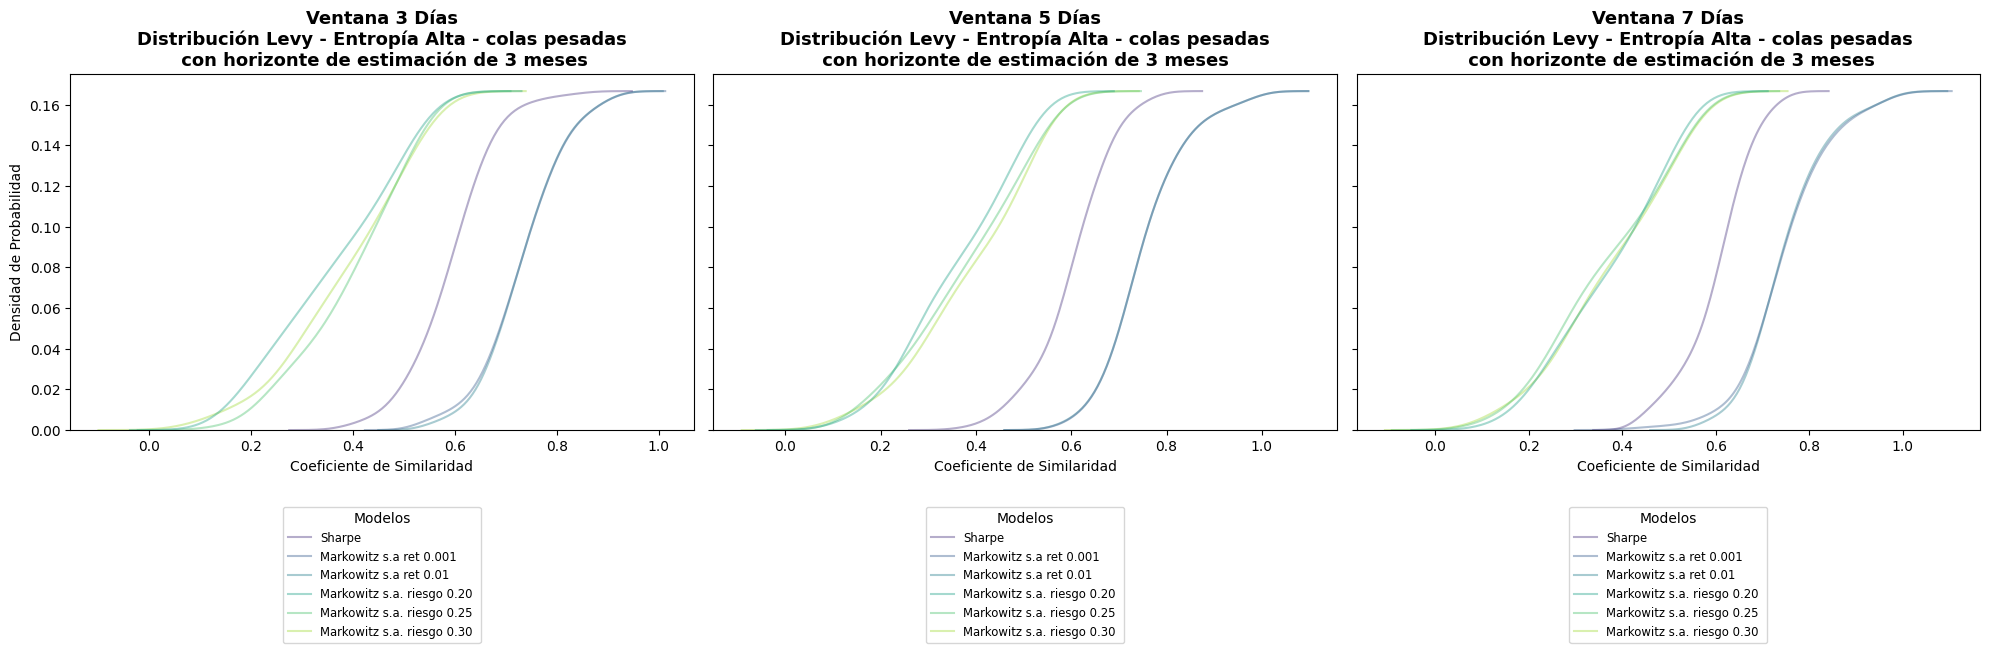

In [27]:
# 1. Configuración de la figura: 1 fila, 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

# Lista de dataframes y sus títulos correspondientes
dfs = [df_similaridad_total_v3, df_similaridad_total_v5, df_similaridad_total_v7]
titulos = [
    'Ventana 3 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses',
    'Ventana 5 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses ',
    'Ventana 7 Días\nDistribución Levy - Entropía Alta - colas pesadas\n con horizonte de estimación de 3 meses'
]

# 2. Iterar sobre los ejes y los datos para generar los KDEs
for i, df in enumerate(dfs):
    # Convertimos de formato ancho a largo para que Seaborn reconozca los modelos como categorías
    df_long = df.melt(var_name='Modelo', value_name='Similaridad')
    
    sns.kdeplot(
        data=df_long,
        x="Similaridad",
        hue="Modelo",
        cumulative=True,
        fill=False,
        ax=axes[i],
        palette="viridis", # Una paleta colorida ayuda a diferenciar modelos
        alpha=0.4,
        linewidth=1.5
    )
    
    axes[i].set_title(titulos[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coeficiente de Similaridad')
    
    # Solo el primer gráfico lleva etiqueta en el eje Y
    if i == 0:
        axes[i].set_ylabel('Densidad de Probabilidad')
    else:
        axes[i].set_ylabel('')

# 3. Ajustes de la leyenda para que no tape el gráfico si hay muchos modelos
for ax in axes:
    sns.move_legend(ax,  fontsize='small', title="Modelos",  loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Ajustes finales
plt.tight_layout()
fig.savefig("imgs_simu/6_Ci_ojiva_comp_v_mdocp_ae", dpi=300, bbox_inches='tight')

In [28]:
v7similar_describe = df_similaridad_total_v7.describe()
kurtosis_values = df_similaridad_total_v7.kurt()
v7similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v7.skew()
v7similar_describe.loc["skew"] = skew_values
v7similar_describe.to_csv("dfdescribe_results/6_v7similar_describe_mdocp_ae", index=True, sep=',', encoding='utf-8')
v7similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,0.599890,0.744557,0.746756,0.372228,0.366007,0.374362
std,0.075633,0.095092,0.086701,0.125982,0.137838,0.136921
min,0.423231,0.405478,0.557703,0.091172,0.062645,0.047090
25%,0.561590,0.693003,0.693003,0.260190,0.259302,0.276481
50%,0.607917,0.733847,0.733099,0.385444,0.360726,0.381739
75%,0.646828,0.792249,0.790830,0.483245,0.495832,0.502050
max,0.755759,0.996947,0.996947,0.568686,0.579672,0.598631
kurt,-0.054642,1.398299,0.654379,-1.114215,-1.160183,-0.870246
skew,-0.484854,0.019771,0.598337,-0.267711,-0.129254,-0.295353


In [29]:
v5similar_describe = df_similaridad_total_v5.describe()
kurtosis_values = df_similaridad_total_v5.kurt()
v5similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v5.skew()
v5similar_describe.loc["skew"] = skew_values
v5similar_describe.to_csv("dfdescribe_results/6_v5similar_describe_mdocp_ae", index=True, sep=',', encoding='utf-8')
v5similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,0.599285,0.749739,0.749522,0.358559,0.376024,0.387199
std,0.082102,0.086100,0.086373,0.121623,0.133345,0.132406
min,0.352688,0.557076,0.557076,0.075858,0.113917,0.058405
25%,0.564696,0.694633,0.694633,0.259314,0.278830,0.288381
50%,0.600797,0.734953,0.734953,0.359621,0.384080,0.397149
75%,0.656915,0.795275,0.795275,0.471019,0.492184,0.508260
max,0.781775,1.000000,1.000000,0.551858,0.595510,0.592147
kurt,0.272759,0.782053,0.778433,-1.011086,-1.029442,-0.701303
skew,-0.382556,0.674990,0.659503,-0.203034,-0.264536,-0.480081


In [30]:
v3similar_describe = df_similaridad_total_v3.describe()
kurtosis_values = df_similaridad_total_v3.kurt()
v3similar_describe.loc["kurt"] = kurtosis_values
skew_values = df_similaridad_total_v3.skew()
v3similar_describe.loc["skew"] = skew_values
v3similar_describe.to_csv("dfdescribe_results/6_v3similar_describe_mdocp_ae", index=True, sep=',', encoding='utf-8')
v3similar_describe

,Sharpe,Markowitz s.a ret 0.001,Markowitz s.a ret 0.01,Markowitz s.a. riesgo 0.20,Markowitz s.a. riesgo 0.25,Markowitz s.a. riesgo 0.30
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,0.590048,0.730101,0.732470,0.360146,0.398673,0.384965
std,0.081186,0.081639,0.077447,0.130865,0.112806,0.129023
min,0.367042,0.516001,0.537530,0.110662,0.105609,0.046853
25%,0.541442,0.675927,0.678405,0.237671,0.325438,0.282141
50%,0.591087,0.728070,0.728122,0.368486,0.416138,0.401163
75%,0.640380,0.785344,0.785344,0.478912,0.498463,0.494704
max,0.855741,0.920695,0.920695,0.583056,0.581986,0.593403
kurt,0.935018,0.313353,0.161131,-1.283755,-0.729154,-0.505965
skew,0.063915,-0.177782,0.022546,-0.150165,-0.443047,-0.484900
